In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()

In [4]:
raw_data_path = "data/CVD_cleaned.csv"
df = pd.read_csv(raw_data_path)

In [3]:
df.head()


,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0


<Axes: >

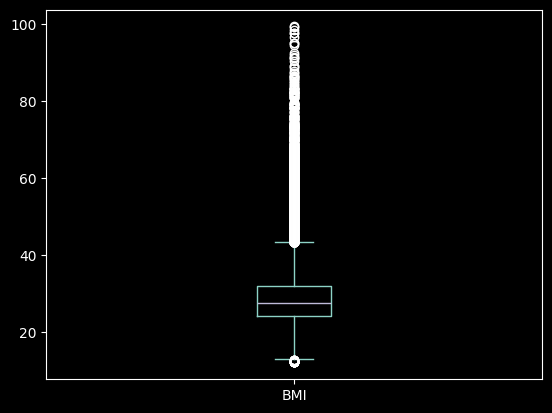

In [7]:
df['BMI'].plot(kind='box')


<Axes: >

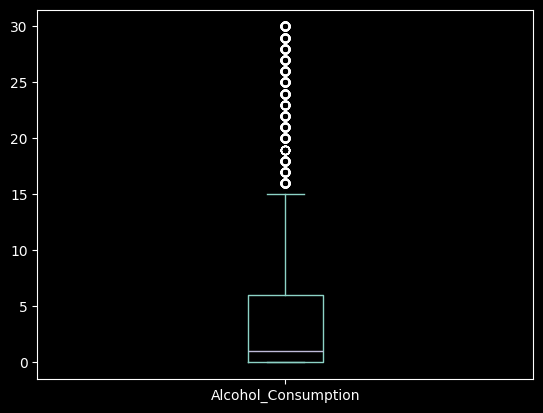

In [6]:
df['Alcohol_Consumption'].plot(kind='box')

<Axes: >

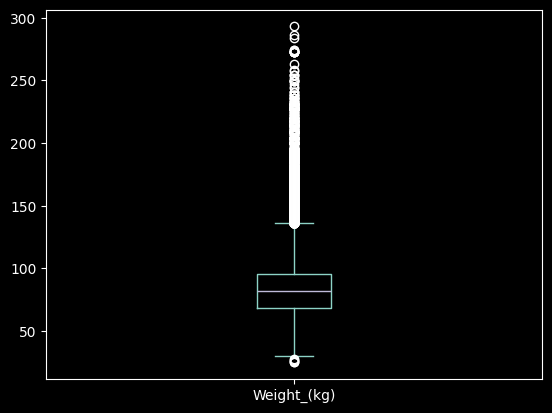

In [9]:
df['Weight_(kg)'].plot(kind='box')

<Axes: >

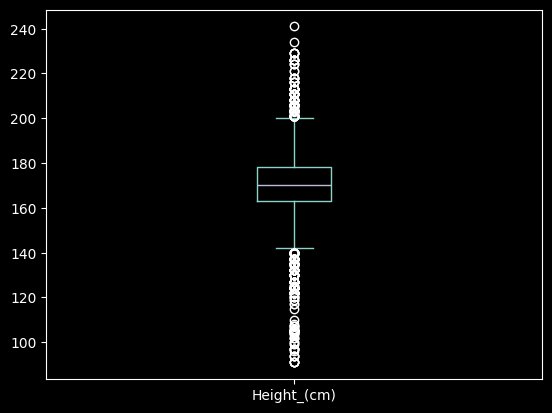

In [10]:
df['Height_(cm)'].plot(kind='box')

<Axes: xlabel='Alcohol_Consumption', ylabel='Count'>

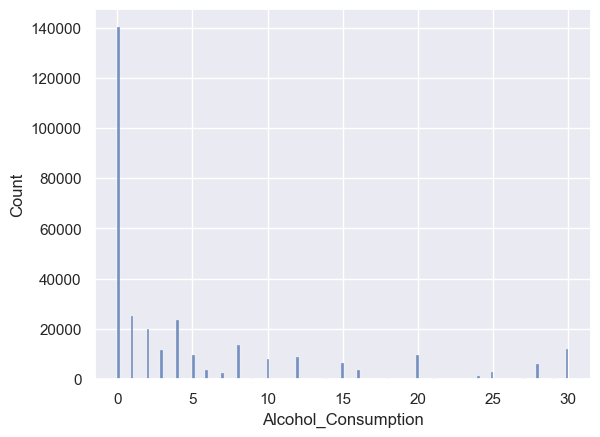

In [15]:
sns.histplot(df['Alcohol_Consumption'])

<Axes: xlabel='Sex', ylabel='Count'>

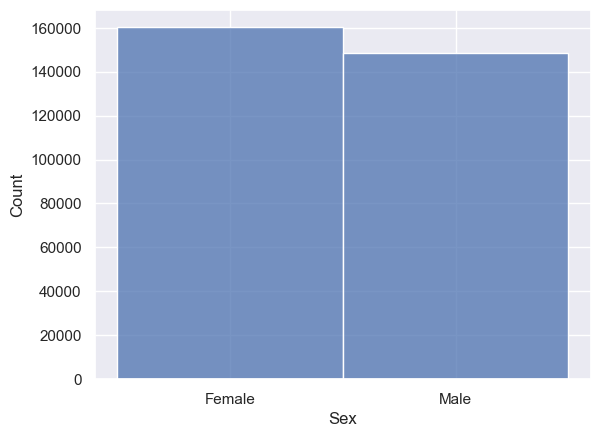

In [25]:
sns.histplot(df['Sex'])

<Axes: xlabel='Height_(cm)', ylabel='Weight_(kg)'>

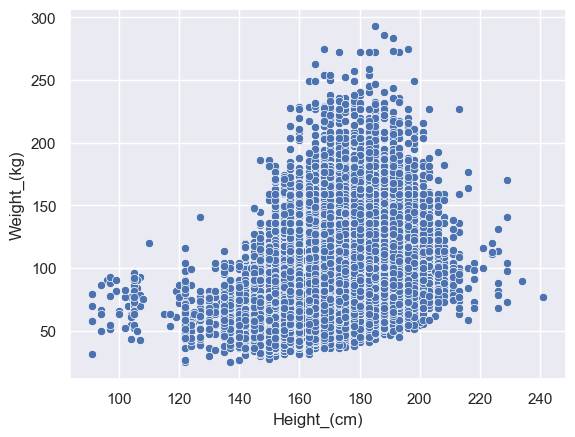

In [23]:
sns.scatterplot(x=df['Height_(cm)'], y=df['Weight_(kg)'])

In [24]:
null_summary = df.isnull().sum()
print(null_summary)

General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype: int64


In [28]:
from sklearn.preprocessing import LabelEncoder

In [31]:
label_encoder = LabelEncoder()

# Female = 0
# Male = 1
df['Sex'] = label_encoder.fit_transform(df['Sex'])

# No = 0
# Yes = 1
df['Smoking_History'] = label_encoder.fit_transform(df['Smoking_History'])


print(df[['Sex', 'Smoking_History']].head())

   Sex  Smoking_History
0    0                1
1    0                0
2    0                0
3    1                0
4    1                1


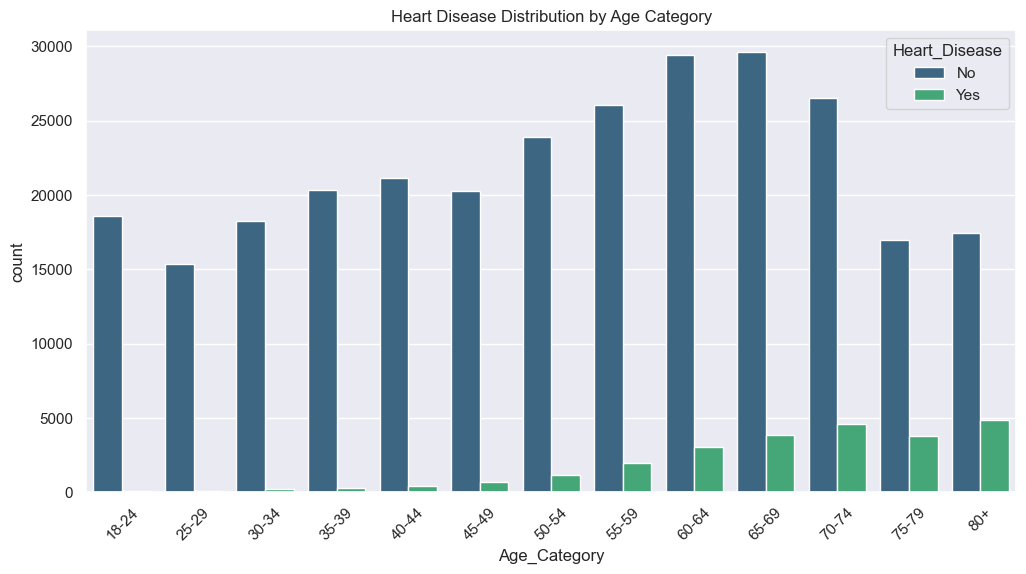

In [6]:
age_order = sorted(df['Age_Category'].unique())

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df,
    x='Age_Category',
    hue='Heart_Disease',
    order=age_order,
    palette='viridis'
)

plt.title('Heart Disease Distribution by Age Category')
plt.xticks(rotation=45)
plt.show()

C:\Users\Luís Silva\AppData\Local\Temp\ipykernel_13548\2883904583.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Heart_Disease', y='BMI', palette='Set2')


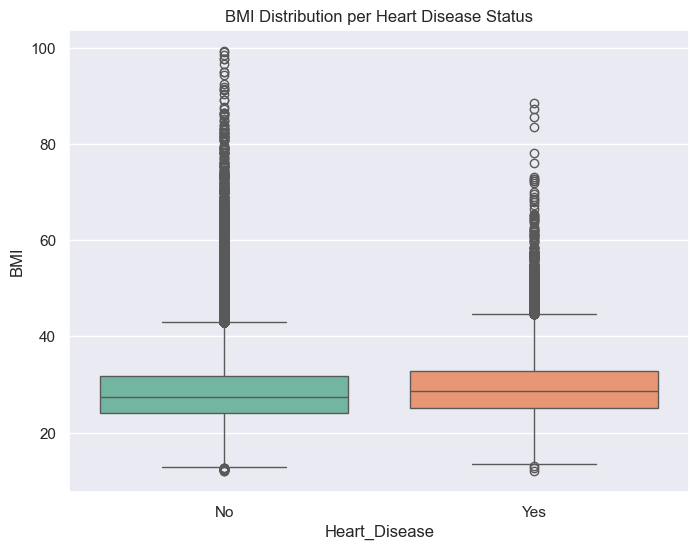

In [4]:
# Comparison: BMI vs Heart Disease
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Heart_Disease', y='BMI', palette='Set2')
plt.title('BMI Distribution per Heart Disease Status')
plt.show()

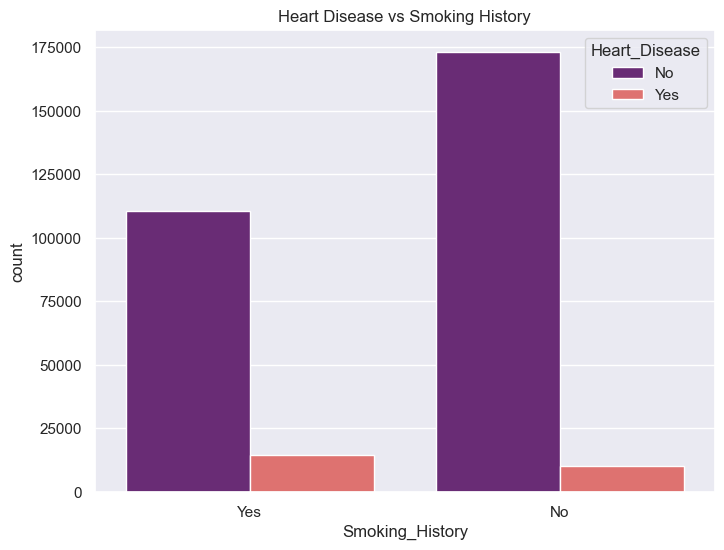

In [7]:
# Comparison: Smoking History vs Heart Disease
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Smoking_History', hue='Heart_Disease', palette='magma')
plt.title('Heart Disease vs Smoking History')
plt.show()

C:\Users\Luís Silva\AppData\Local\Temp\ipykernel_13548\3453322413.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


<Figure size 1500x800 with 0 Axes>

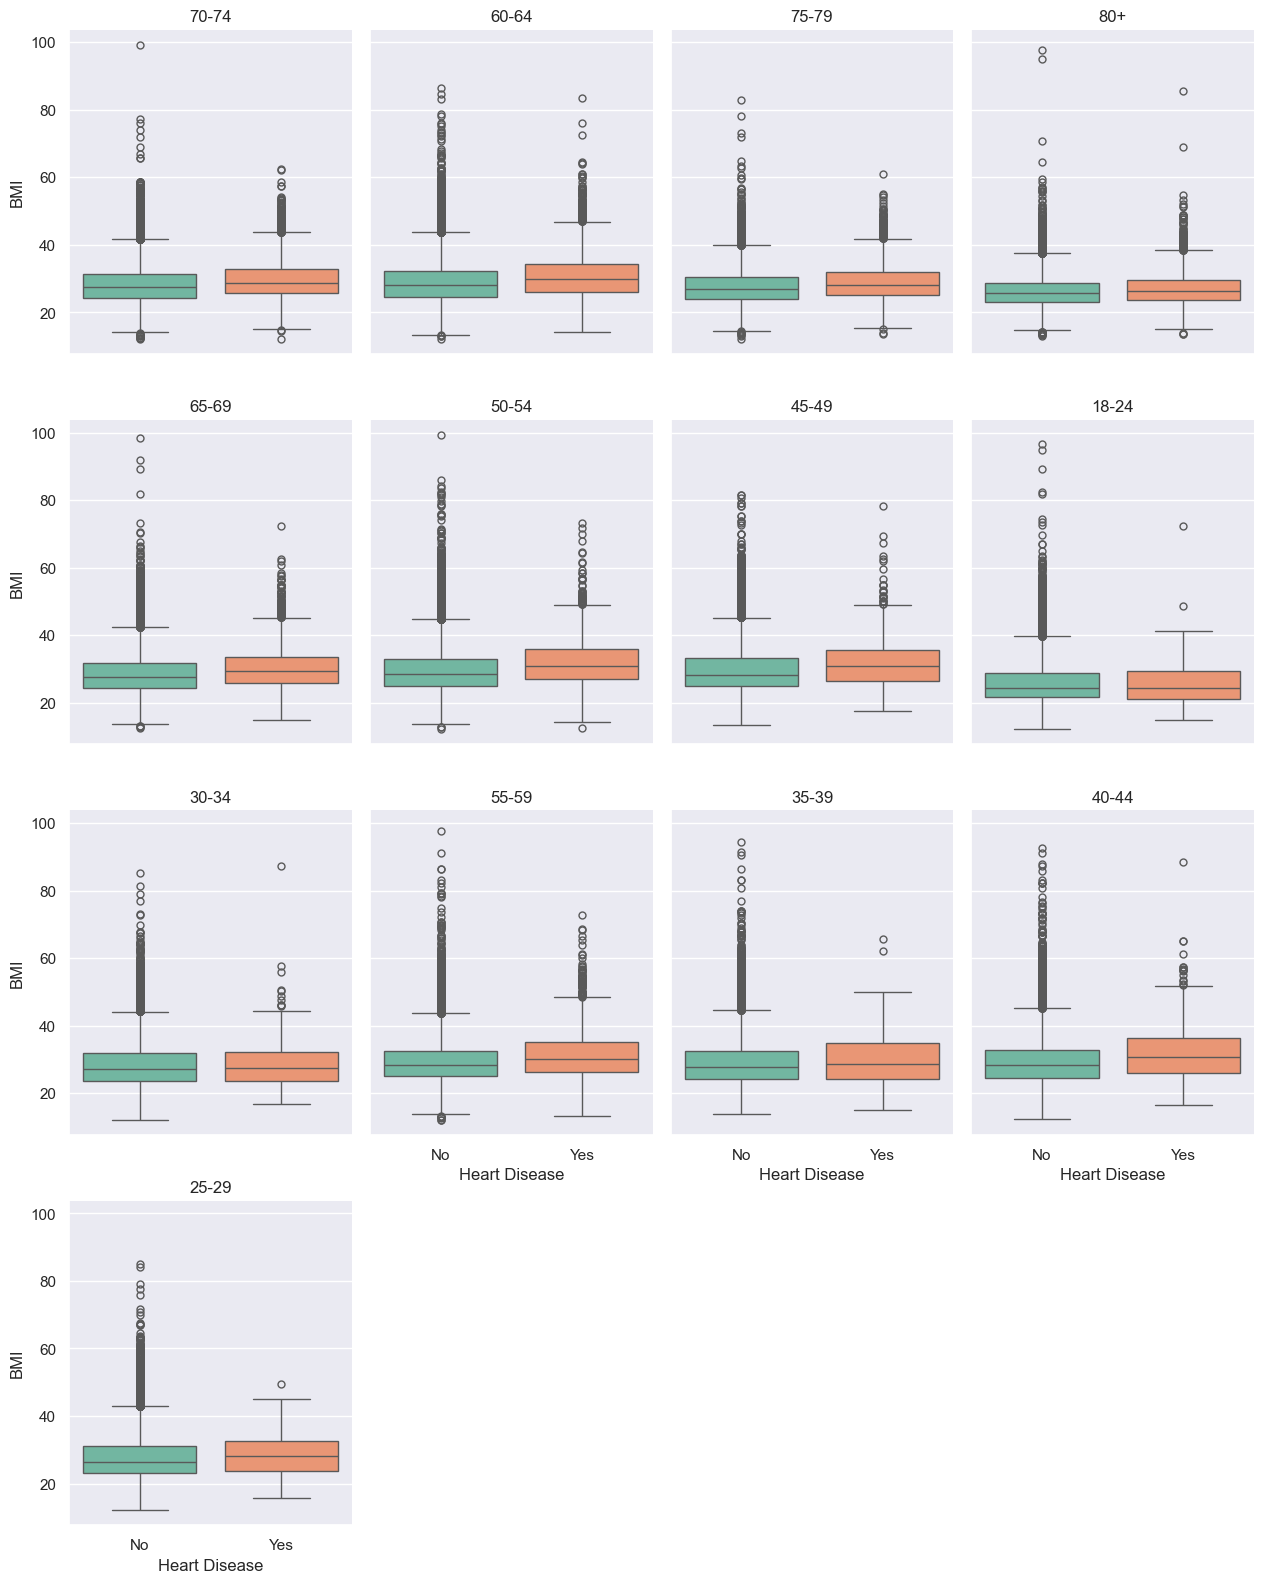

In [8]:
plt.figure(figsize=(15, 8))
g = sns.catplot(
    data=df,
    x='Heart_Disease',
    y='BMI',
    col='Age_Category', # This creates one subplot per age group
    col_wrap=4,         # Limits to 4 columns per row for better layout
    kind='box',
    palette='Set2',
    height=4,
    aspect=0.8
)
g.set_axis_labels("Heart Disease", "BMI")
g.set_titles("{col_name}")
plt.show()

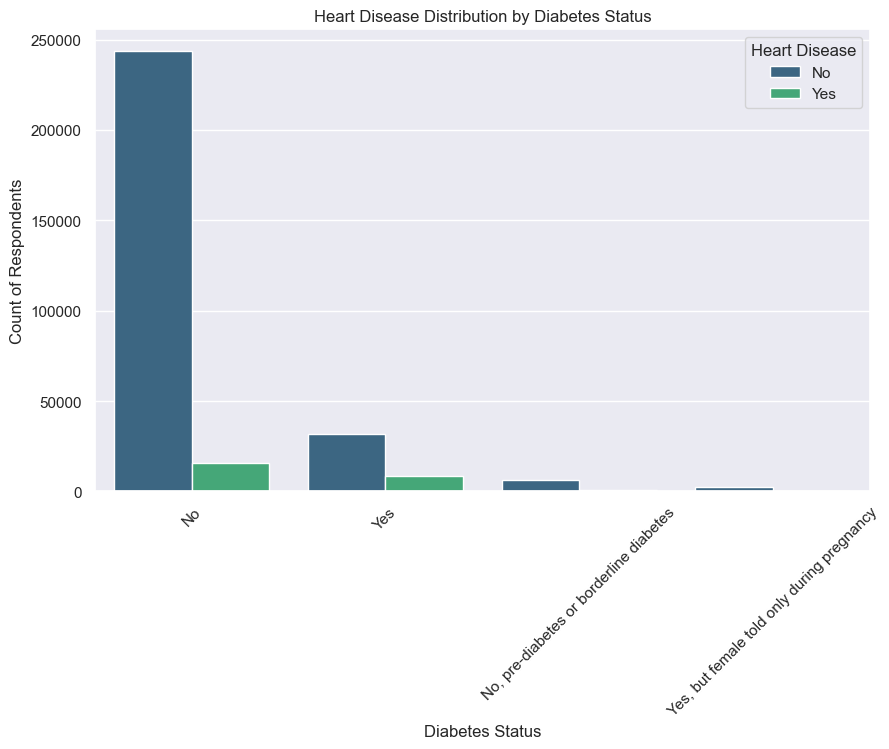

In [9]:
plt.figure(figsize=(10, 6))

# We use countplot because both are categorical variables
sns.countplot(
    data=df,
    x='Diabetes',
    hue='Heart_Disease',
    palette='viridis'
)

plt.title('Heart Disease Distribution by Diabetes Status')
plt.xlabel('Diabetes Status')
plt.ylabel('Count of Respondents')
plt.xticks(rotation=45) # Rotate labels if they overlap
plt.legend(title='Heart Disease', loc='upper right')
plt.show()

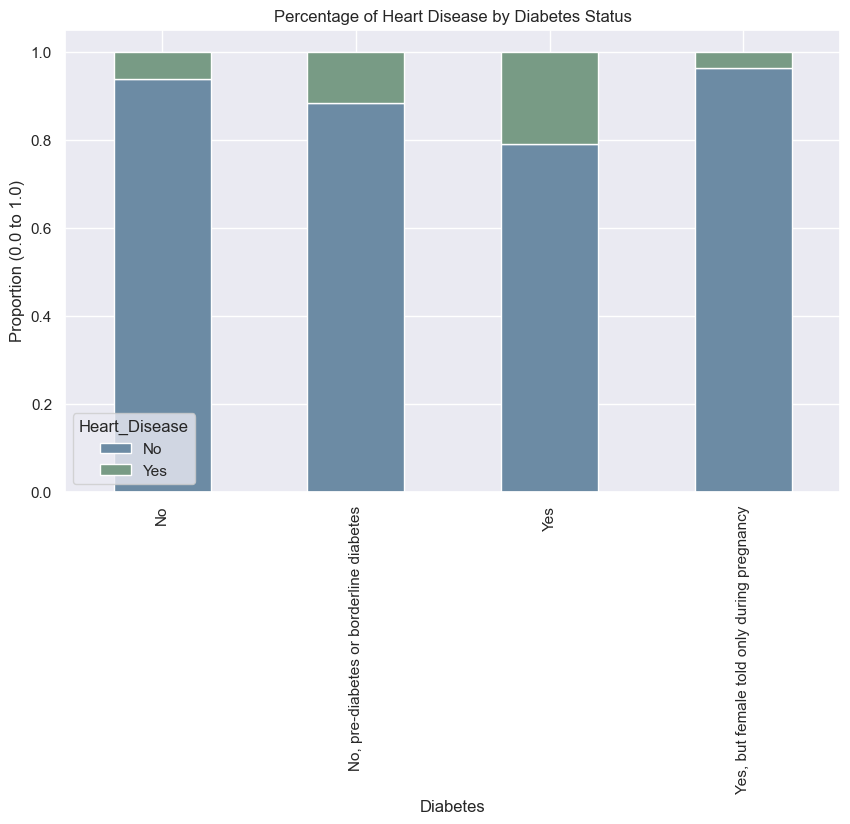

In [10]:
# Create a normalized crosstab (percentages)
diabetes_heart_pct = pd.crosstab(df['Diabetes'], df['Heart_Disease'], normalize='index')

# Plot the normalized data
diabetes_heart_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#6c8ba4', '#789b85'])
plt.title('Percentage of Heart Disease by Diabetes Status')
plt.ylabel('Proportion (0.0 to 1.0)')
plt.show()

In [19]:
print(df.columns.tolist())
print(df[['Height_(cm)', 'Weight_(kg)']].dtypes)
print(df[['Height_(cm)', 'Weight_(kg)']].head())

['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Smoking_History', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption', 'BMI_Category', 'Height_Category', 'Weight_Category', 'Alcohol_Category', 'Fruit_Category', 'Veg_Category']
Height_(cm)    float64
Weight_(kg)    float64
dtype: object
   Height_(cm)  Weight_(kg)
0          NaN          NaN
1          NaN          NaN
2          NaN          NaN
3          NaN          NaN
4          NaN          NaN


In [20]:
# Ver todas as colunas com valores não-nulos
print(df.notna().sum().sort_values(ascending=False))

# Ver as primeiras linhas do dataframe completo
print(df.head())

# Ver especificamente as colunas de altura e peso
print(df[['Height_(cm)', 'Weight_(kg)']].describe())

General_Health                  308854
Checkup                         308854
Exercise                        308854
Heart_Disease                   308854
Skin_Cancer                     308854
Other_Cancer                    308854
Depression                      308854
Diabetes                        308854
Arthritis                       308854
Sex                             308854
Age_Category                    308854
Smoking_History                 308854
Veg_Category                    308854
Weight_Category                 308854
Alcohol_Category                308854
Fruit_Category                  308854
Height_Category                 308854
Fruit_Consumption                    0
Alcohol_Consumption                  0
BMI                                  0
Weight_(kg)                          0
Height_(cm)                          0
BMI_Category                         0
Green_Vegetables_Consumption         0
FriedPotato_Consumption              0
dtype: int64
  General_He

In [21]:
# Secção 3.3
# PASSO 0: Recarregar o dataset limpo
df = pd.read_csv("data/CVD_cleaned.csv")

# Binarização do Sex e Smoking_History (repetir aqui após reload)
df['Sex'] = df['Sex'].map({'Male': 1, 'Female': 0})
df['Smoking_History'] = df['Smoking_History'].map({'Yes': 1, 'No': 0})

# Criar cópia para versão categórica
df_cat = df.copy()

# BMI
df_cat['BMI_Category'] = pd.cut(
    df_cat['BMI'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

# Altura e Peso
df_cat['Height_Category'] = pd.cut(
    df_cat['Height_(cm)'],
    bins=[0, 163, 178, 300],
    labels=['Short', 'Average', 'Tall']
)
df_cat['Weight_Category'] = pd.cut(
    df_cat['Weight_(kg)'],
    bins=[0, 65, 90, 500],
    labels=['Light', 'Average', 'Heavy']
)

# Consumos
df_cat['Alcohol_Category'] = pd.cut(
    df_cat['Alcohol_Consumption'],
    bins=[-1, 0, 15, 500],
    labels=['None', 'Moderate', 'High']
)

food_bins = [-1, 10, 30, 500]
food_labels = ['Low', 'Medium', 'High']
df_cat['Fruit_Category']  = pd.cut(df_cat['Fruit_Consumption'], bins=food_bins, labels=food_labels)
df_cat['Veg_Category']    = pd.cut(df_cat['Green_Vegetables_Consumption'], bins=food_bins, labels=food_labels)
df_cat['Potato_Category'] = pd.cut(df_cat['FriedPotato_Consumption'], bins=food_bins, labels=food_labels)

print(df_cat[['BMI_Category', 'Height_Category', 'Weight_Category', 'Potato_Category']].head(10))

  BMI_Category Height_Category Weight_Category Potato_Category
0  Underweight           Short           Light          Medium
1   Overweight         Average         Average             Low
2        Obese           Short         Average          Medium
3   Overweight            Tall           Heavy             Low
4       Normal            Tall         Average             Low
5        Obese            Tall           Heavy          Medium
6       Normal         Average         Average             Low
7        Obese         Average           Heavy             Low
8   Overweight           Short         Average             Low
9        Obese           Short           Heavy             Low


In [23]:
# Secção 3.2
df_num = df.copy()

# Variáveis Yes/No → 0/1
yes_no_cols = ['Exercise', 'Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Arthritis']
for col in yes_no_cols:
    df_num[col] = df_num[col].map({'Yes': 1, 'No': 0})

# General_Health — ordinal
df_num['General_Health'] = df_num['General_Health'].map({
    'Poor': 1, 'Fair': 2, 'Good': 3, 'Very Good': 4, 'Excellent': 5
})

# Checkup — ordinal (quanto mais recente, maior o valor)
df_num['Checkup'] = df_num['Checkup'].map({
    'Never': 0,
    '5 or more years ago': 1,
    'Within the past 5 years': 2,
    'Within the past 2 years': 3,
    'Within the past year': 4
})

# Age_Category — ordinal
age_order = ['18-24','25-29','30-34','35-39','40-44','45-49',
             '50-54','55-59','60-64','65-69','70-74','75-79','80+']
df_num['Age_Category'] = df_num['Age_Category'].map({a: i for i, a in enumerate(age_order)})

# Diabetes — tem mais categorias
df_num['Diabetes'] = df_num['Diabetes'].map({
    'No': 0,
    'No, pre-diabetes or borderline diabetes': 1,
    'Yes, but female told only during pregnancy': 2,
    'Yes': 3
})

print(df_num.dtypes)
print(df_num.head())

General_Health                    int64
Checkup                           int64
Exercise                          int64
Heart_Disease                     int64
Skin_Cancer                       int64
Other_Cancer                      int64
Depression                        int64
Diabetes                          int64
Arthritis                         int64
Sex                               int64
Age_Category                      int64
Height_(cm)                     float64
Weight_(kg)                     float64
BMI                             float64
Smoking_History                   int64
Alcohol_Consumption             float64
Fruit_Consumption               float64
Green_Vegetables_Consumption    float64
FriedPotato_Consumption         float64
dtype: object
   General_Health  Checkup  Exercise  Heart_Disease  Skin_Cancer  \
0               1        3         0              0            0   
1               4        4         0              1            0   
2               4     

In [25]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Secção 3.4
# StandardScaler
scaler_std = StandardScaler()
df_std = pd.DataFrame(scaler_std.fit_transform(df_num), columns=df_num.columns)

# MinMaxScaler
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df_num), columns=df_num.columns)

# Verificar resultados
print("=== StandardScaler ===")
print(df_std.describe().round(2))

print("\n=== MinMaxScaler ===")
print(df_minmax.describe().round(2))

=== StandardScaler ===
       General_Health    Checkup   Exercise  Heart_Disease  Skin_Cancer  \
count       308854.00  308854.00  308854.00      308854.00    308854.00   
mean            -0.00       0.00       0.00           0.00        -0.00   
std              1.00       1.00       1.00           1.00         1.00   
min             -2.45      -4.44      -1.86          -0.30        -0.33   
25%             -0.51       0.47       0.54          -0.30        -0.33   
50%              0.46       0.47       0.54          -0.30        -0.33   
75%              0.46       0.47       0.54          -0.30        -0.33   
max              1.43       0.47       0.54           3.37         3.05   

       Other_Cancer  Depression   Diabetes  Arthritis        Sex  \
count     308854.00    308854.0  308854.00  308854.00  308854.00   
mean          -0.00         0.0       0.00      -0.00      -0.00   
std            1.00         1.0       1.00       1.00       1.00   
min           -0.33        -0